In [1]:
import pandas as pd
import numpy as np
import re

# Reading Data
df = pd.read_csv("../Dataset/heritage_sites_v2.csv")

# Year Extraction
def extract_year(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    m = re.search(r'(\d+)', s)
    if not m:
        return np.nan
    
    year = int(m.group(1))
    if "BCE" in s:
        return -year
    return year
df['YearNum'] = df['Year(midpoint)'].apply(extract_year)


# Popularity Mapping
pop_map = {
    'Very high': 4,
    'High': 3,
    'Good': 2,
    'Moderate': 1,
    'Low': 0,
    'Moderate-High': (1 + 3) / 2,    
    'Low-Moderate': (0 + 1) / 2      
}
df['PopularityNum'] = df['Popularity'].map(pop_map)

# Preservation Mapping
pres_map = {
    'Excellent': 4, 
    'Good': 3, 
    'Moderate': 2, 
    'Partially ruined, preserved': 1,
    'Ruins preversed': 0
}
df['PreservationNum'] = df['Preservation'].map(pres_map)

In [ ]:
from sentence_transformers import SentenceTransformer
# Text Embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

df['ArchEmbed'] = list(model.encode(df['Architecture Style'].astype(str)))
df['MatEmbed'] = list(model.encode(df['Material'].astype(str)))
df['StructEmbed'] = list(model.encode(df['Structure'].astype(str)))

In [3]:
import ast
# Arrays
def to_vec(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x))
    return np.array(x)

df["ArchVec"] = df["ArchEmbed"].apply(to_vec)
df["MatVec"] = df["MatEmbed"].apply(to_vec)
df["StructVec"] = df["StructEmbed"].apply(to_vec)

In [4]:
df.head()

,Name,Country,Continent,Era,Year(midpoint),Civilization,Religion,Architecture Style,Material,Structure,...,Popularity,YearNum,PopularityNum,PreservationNum,ArchEmbed,MatEmbed,StructEmbed,ArchVec,MatVec,StructVec
0,Great Temple (Petra),Jordan,Asia,1st century AD,50 AD,Nabataean Kingdom,Nabataean,Nabataean temple architecture,Sandstone,"dromos, colonnades, theater",...,High,50,3.0,2.0,"[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014...","[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014..."
1,Ajanta Caves,India,Asia,2nd century BCE - 6th century CE,200 CE,Ancient Indian (Buddhist),Buddhism,Rock-cut cave architecture,Basalt,30 caves,...,High,200,3.0,3.0,"[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037...","[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037..."
2,Ellora Caves,India,Asia,6th - 10th century CE,800 CE,Rashtrakuta / Yadava India,Hinduism / Buddhism / Jainism,Rock-cut monolithic architecture,Basalt,34 caves,...,High,800,3.0,3.0,"[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038...","[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038..."
3,Konark Sun Temple,India,Asia,c. 1250 CE,1250 CE,Eastern Ganga dynasty,Hinduism,Kalinga (temple as chariot),Sandstone / laterite,Temple with 24 wheels and 7 horses,...,High,1250,3.0,1.0,"[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01...","[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01..."
4,Pattadakal,India,Asia,7th - 8th century AD,700 AD,Chalukya India,Hinduism / Jainism,Blend of Nagara / Dravidian styles,Sandstone / carved stone,Group of temples,...,Moderate,700,1.0,3.0,"[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04...","[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04..."


In [5]:
df.to_html("preprocessed_table.html")

In [6]:
# Assigning Features
scalar_features = ['Area(m2)', 'YearNum', 'PopularityNum', 'PreservationNum']
vector_features = ['ArchVec', 'MatVec', 'StructVec']


df[scalar_features] = df[scalar_features].fillna(df[scalar_features].median())
Arch = np.stack(df['ArchVec'].values)
Mat = np.stack(df['MatVec'].values)
Struct = np.stack(df['StructVec'].values)

In [7]:
# Final Features
X = np.hstack([
    df[scalar_features].values,
    Arch,
    Mat,
    Struct
])

In [8]:
# Feature Sets
feature_sets = {
    "Only_Scalar": {
        "scalar": scalar_features,
        "use_arch": False,
        "use_mat": False,
        "use_struct": False
    },
    "Scalar_Arch": {
        "scalar": scalar_features,
        "use_arch": True,
        "use_mat": False,
        "use_struct": False
    },
    "Scalar_Arch_Mat": {
        "scalar": scalar_features,
        "use_arch": True,
        "use_mat": True,
        "use_struct": False
    },
    "All_Features": {
        "scalar": scalar_features,
        "use_arch": True,
        "use_mat": True,
        "use_struct": True
    },
    "Arch_Mat_Struct": {
        "scalar": [],
        "use_arch": True,
        "use_mat": True,
        "use_struct": True
    }
}


##### KMeans

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

for cluster_name, cfg in feature_sets.items():

    parts = []

    if len(cfg["scalar"]) > 0:
        parts.append(df[cfg["scalar"]].values)

    if cfg["use_arch"]:
        parts.append(Arch)

    if cfg["use_mat"]:
        parts.append(Mat)

    if cfg["use_struct"]:
        parts.append(Struct)

    X = np.hstack(parts)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=12, random_state=0)
    df[f"{cluster_name}_KMeans"] = kmeans.fit_predict(X_scaled)


##### DBSCAN not able to cluster properly as it is calculating more noise

In [ ]:
""""
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

for cluster_name, cfg in feature_sets.items():

    parts = []

    if len(cfg["scalar"]) > 0:
        parts.append(df[cfg["scalar"]].values)

    if cfg["use_arch"]:
        parts.append(Arch)

    if cfg["use_mat"]:
        parts.append(Mat)

    if cfg["use_struct"]:
        parts.append(Struct)

    X = np.hstack(parts)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    db = DBSCAN(eps=2, min_samples=2)
    df[cluster_name] = db.fit_predict(X_scaled)
"""

##### AGNES

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

for cluster_name, cfg in feature_sets.items():

    parts = []

    if len(cfg["scalar"]) > 0:
        parts.append(df[cfg["scalar"]].values)

    if cfg["use_arch"]:
        parts.append(Arch)

    if cfg["use_mat"]:
        parts.append(Mat)

    if cfg["use_struct"]:
        parts.append(Struct)

    X = np.hstack(parts)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    agnes = AgglomerativeClustering(
    n_clusters=12,
    linkage='ward'
    )
    df[f"{cluster_name}_AGNES"] = agnes.fit_predict(X_scaled)

##### Gaussian

In [11]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

for cluster_name, cfg in feature_sets.items():

    parts = []

    if len(cfg["scalar"]) > 0:
        parts.append(df[cfg["scalar"]].values)

    if cfg["use_arch"]:
        parts.append(Arch)

    if cfg["use_mat"]:
        parts.append(Mat)

    if cfg["use_struct"]:
        parts.append(Struct)

    X = np.hstack(parts)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = X_scaled.astype(np.float64)

    gmm = GaussianMixture(
    n_components=12,
    covariance_type='full', 
    random_state=42,
    reg_covar=1e-3
    )
    df[f'{cluster_name}_GMM'] = gmm.fit_predict(X_scaled)

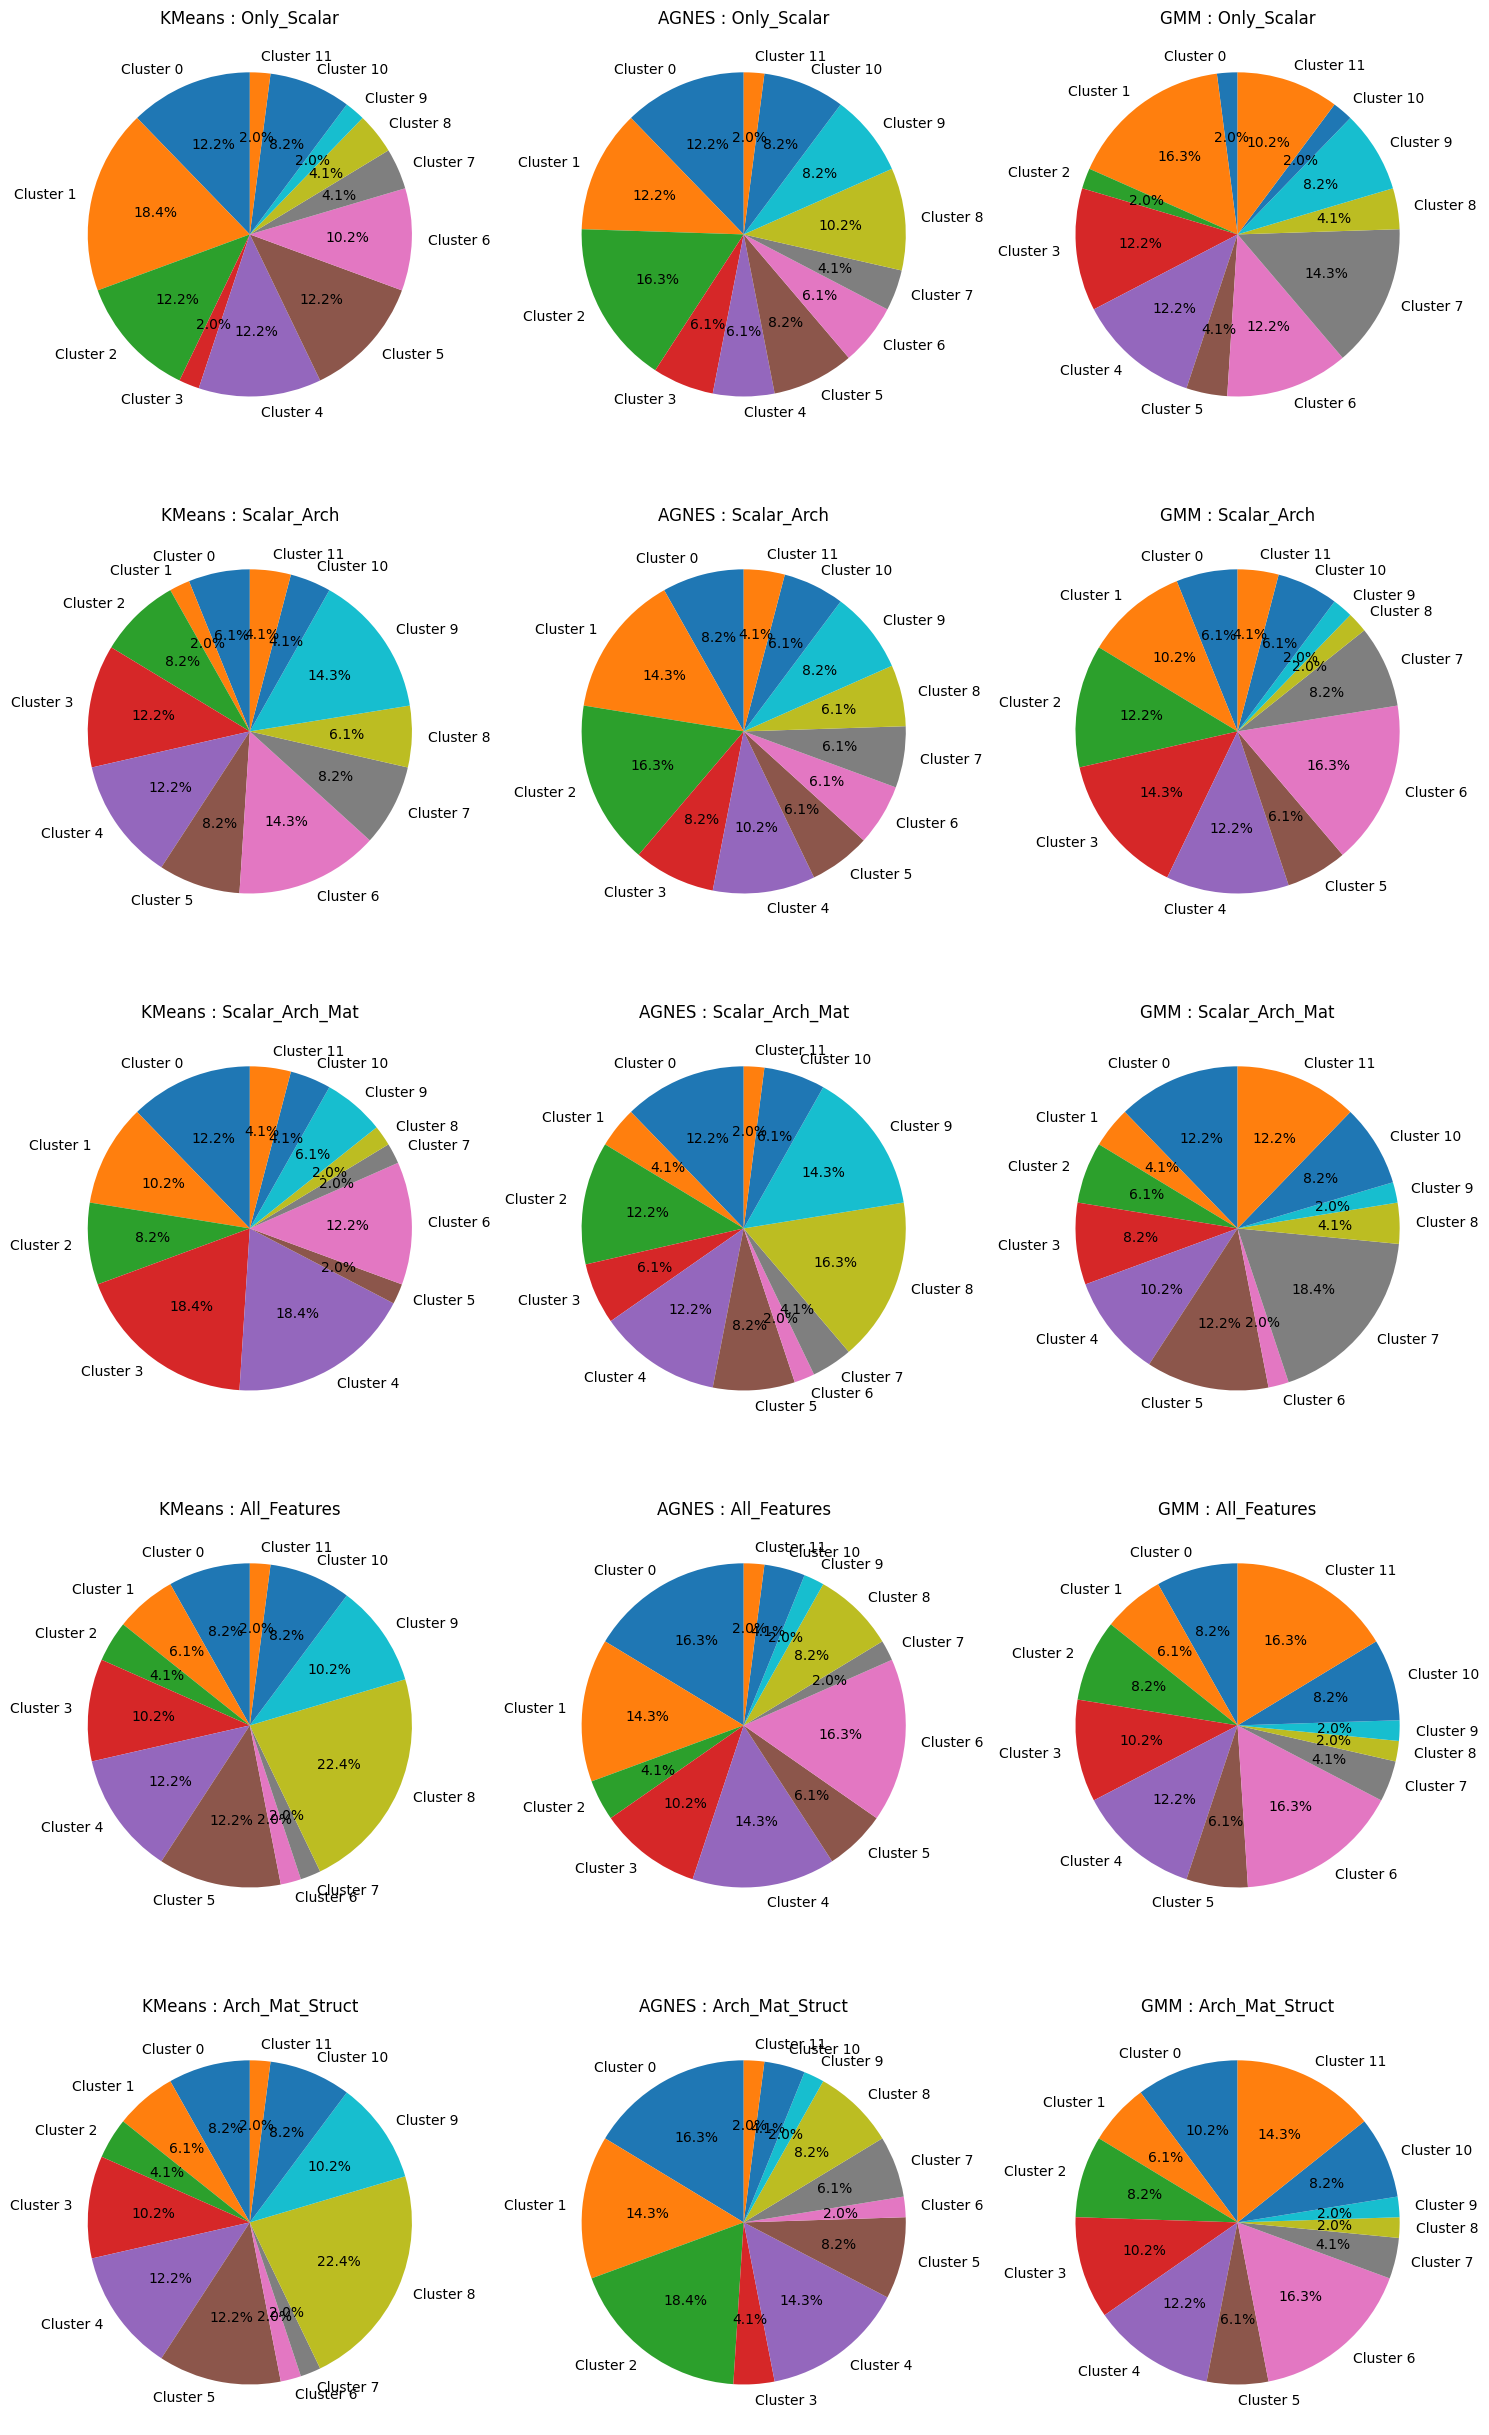

In [12]:
import matplotlib.pyplot as plt

methods = ["KMeans", "AGNES", "GMM"]
cluster_names = feature_sets.keys()

total_plots = len(cluster_names) * len(methods)
cols = 3
rows = (total_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
axes = axes.flatten()

plot_idx = 0
for cluster_name in cluster_names:
    for method in methods:
        col = f"{cluster_name}_{method}"  
        counts = df[col].value_counts().sort_index()

        axes[plot_idx].pie(
            counts, 
            labels=[f"Cluster {i}" for i in counts.index],
            autopct='%1.1f%%', 
            startangle=90
        )
        axes[plot_idx].set_title(f"{method} : {cluster_name}")
        plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("plot.png")
plt.show()

##### Cosine

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)
site_names = df['Name'].tolist()

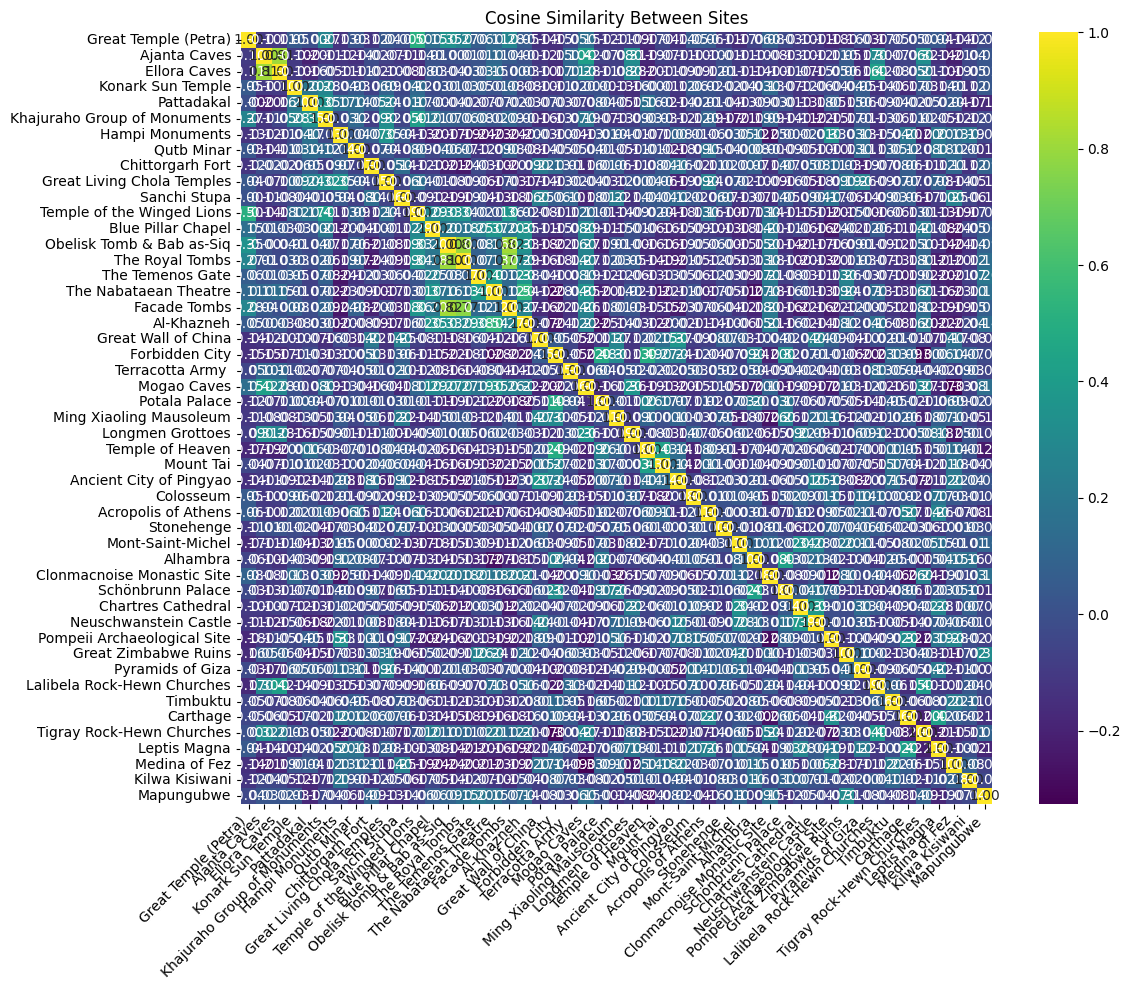

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

similarity_matrix = cosine_similarity(X_scaled)

plt.figure(figsize=(12,10))
sns.heatmap(similarity_matrix, 
            xticklabels=site_names, 
            yticklabels=site_names, 
            cmap='viridis',      
            annot=True,          
            fmt=".2f")           
plt.title("Cosine Similarity Between Sites")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cosine_similarity_heatmap.png")  
plt.show()

##### Similarity Checks

In [81]:
def get_top_similar(site_name, feature_set_name="All_Features", top_k=5):
    if site_name not in site_names:
        return []

    idx = site_names.index(site_name)
    sims = similarity_matrix[idx]

    similar_indices = np.argsort(sims)[::-1][1:top_k+1]

    results = []
    for i in similar_indices:
        results.append({
            "name": site_names[i],
            "similarity": float(sims[i]),
            "kmeans_cluster": int(df.loc[i, f"{feature_set_name}_KMeans"]),
            "agnes_cluster": int(df.loc[i, f"{feature_set_name}_AGNES"]),
            "gmm_cluster": int(df.loc[i, f"{feature_set_name}_GMM"])
        })
    return results

In [82]:
def get_similar_within_cluster(site_name, feature_set_name="All_Features", method="KMeans", top_k=5):
    if site_name not in site_names:
        return []

    idx = site_names.index(site_name)
    cluster_col = f"{feature_set_name}_{method}"  
    site_cluster = df.loc[idx, cluster_col]

    mask = df[cluster_col] == site_cluster
    cluster_indices = np.where(mask)[0]

    sims = similarity_matrix[idx]
    filtered = [(i, sims[i]) for i in cluster_indices if i != idx]

    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[:top_k]

    return [(site_names[i], float(score)) for i, score in filtered]

In [ ]:
"""
def get_similar_within_cluster(site_name, cluster_type="DBSCANCluster", top_k=5):
    idx = site_names.index(site_name)
    site_cluster = df.loc[idx, cluster_type]

    mask = df[cluster_type] == site_cluster
    cluster_indices = np.where(mask)[0]

    sims = similarity_matrix[idx]
    filtered = [(i, sims[i]) for i in cluster_indices if i != idx]
    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[:top_k]

    return [(site_names[i], float(score)) for i, score in filtered]
"""

In [85]:
def get_similar_within_cluster(site_name, feature_set_name="All_Features", method="AGNES", top_k=5):
    if site_name not in site_names:
        return []

    idx = site_names.index(site_name)
    cluster_col = f"{feature_set_name}_{method}"  
    site_cluster = df.loc[idx, cluster_col]

    mask = df[cluster_col] == site_cluster
    cluster_indices = np.where(mask)[0]

    sims = similarity_matrix[idx]
    filtered = [(i, sims[i]) for i in cluster_indices if i != idx]

    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[:top_k]

    return [(site_names[i], float(score)) for i, score in filtered]

In [84]:
def get_similar_within_cluster(site_name, feature_set_name="All_Features", method="GMM", top_k=5):
    if site_name not in site_names:
        return []

    idx = site_names.index(site_name)
    cluster_col = f"{feature_set_name}_{method}"  
    site_cluster = df.loc[idx, cluster_col]

    mask = df[cluster_col] == site_cluster
    cluster_indices = np.where(mask)[0]

    sims = similarity_matrix[idx]
    filtered = [(i, sims[i]) for i in cluster_indices if i != idx]

    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[:top_k]

    return [(site_names[i], float(score)) for i, score in filtered]

### Example

In [86]:
target = "Ajanta Caves"

print("Top 5 Similar:")
print(get_top_similar(target, feature_set_name="All_Features", top_k=5))

print("\nTop 5 Similar in Same Cluster KMeans:")
print(get_similar_within_cluster(target, feature_set_name="All_Features", method="KMeans", top_k=5))

print("\nTop 5 Similar in Same Cluster AGNES:")
print(get_similar_within_cluster(target, feature_set_name="All_Features", method="AGNES", top_k=5))

print("\nTop 5 Similar in Same Cluster GMM:")
print(get_similar_within_cluster(target, feature_set_name="All_Features", method="GMM", top_k=5))

Top 5 Similar:
[{'name': 'Ellora Caves', 'similarity': 0.8131117730632592, 'kmeans_cluster': 9, 'agnes_cluster': 3, 'gmm_cluster': 2}, {'name': 'Mogao Caves', 'similarity': 0.4190686949475261, 'kmeans_cluster': 9, 'agnes_cluster': 3, 'gmm_cluster': 11}, {'name': 'Tigray Rock-Hewn Churches', 'similarity': 0.32254758731718375, 'kmeans_cluster': 2, 'agnes_cluster': 6, 'gmm_cluster': 11}, {'name': 'Longmen Grottoes', 'similarity': 0.31225638211761975, 'kmeans_cluster': 9, 'agnes_cluster': 3, 'gmm_cluster': 2}, {'name': 'Lalibela Rock-Hewn Churches', 'similarity': 0.2984294497527221, 'kmeans_cluster': 2, 'agnes_cluster': 3, 'gmm_cluster': 2}]

Top 5 Similar in Same Cluster KMeans:
[('Ellora Caves', 0.8131117730632592), ('Mogao Caves', 0.4190686949475261), ('Longmen Grottoes', 0.31225638211761975), ('Terracotta Army ', 0.10392858887106905)]

Top 5 Similar in Same Cluster AGNES:
[('Ellora Caves', 0.8131117730632592), ('Mogao Caves', 0.4190686949475261), ('Longmen Grottoes', 0.3122563821176197

In [91]:
import json

target = "Ajanta Caves"

out1 = get_top_similar(target, feature_set_name="All_Features", top_k=5)
out2 = get_similar_within_cluster(target, feature_set_name="All_Features", method="KMeans", top_k=5)
out3 = get_similar_within_cluster(target, feature_set_name="All_Features", method="AGNES", top_k=5)
out4 = get_similar_within_cluster(target, feature_set_name="All_Features", method="GMM", top_k=5)

results = {
    "Top 5 Similar": out1,
    "Top 5 Similar (KMeans)": out2,
    "Top 5 Similar (AGNES)": out3,
    "Top 5 Similar (GMM)": out4
}

print(json.dumps(results, indent=4))

{
    "Top 5 Similar": [
        {
            "name": "Ellora Caves",
            "similarity": 0.8131117730632592,
            "kmeans_cluster": 9,
            "agnes_cluster": 3,
            "gmm_cluster": 2
        },
        {
            "name": "Mogao Caves",
            "similarity": 0.4190686949475261,
            "kmeans_cluster": 9,
            "agnes_cluster": 3,
            "gmm_cluster": 11
        },
        {
            "name": "Tigray Rock-Hewn Churches",
            "similarity": 0.32254758731718375,
            "kmeans_cluster": 2,
            "agnes_cluster": 6,
            "gmm_cluster": 11
        },
        {
            "name": "Longmen Grottoes",
            "similarity": 0.31225638211761975,
            "kmeans_cluster": 9,
            "agnes_cluster": 3,
            "gmm_cluster": 2
        },
        {
            "name": "Lalibela Rock-Hewn Churches",
            "similarity": 0.2984294497527221,
            "kmeans_cluster": 2,
            "agnes_cluster"

In [90]:
import pickle

df.to_pickle("Pickles/df.pkl")

pickle.dump(X, open("Pickles/X.pkl", "wb"))
pickle.dump(Arch, open("Pickles/Arch.pkl", "wb"))
pickle.dump(Mat, open("Pickles/Mat.pkl", "wb"))
pickle.dump(Struct, open("Pickles/Struct.pkl", "wb"))

pickle.dump(feature_sets, open("Pickles/feature_sets.pkl", "wb"))

pickle.dump(similarity_matrix, open("Pickles/similarity.pkl", "wb"))
pickle.dump(site_names, open("Pickles/site_names.pkl", "wb"))

In [2]:
import pandas as pd

df = pd.read_html("preprocessed_table.html")[0]

In [3]:
df.head()

,Unnamed: 0,Name,Country,Continent,Era,Year(midpoint),Civilization,Religion,Architecture Style,Material,...,Popularity,YearNum,PopularityNum,PreservationNum,ArchEmbed,MatEmbed,StructEmbed,ArchVec,MatVec,StructVec
0,0,Great Temple (Petra),Jordan,Asia,1st century AD,50 AD,Nabataean Kingdom,Nabataean,Nabataean temple architecture,Sandstone,...,High,50,3.0,2.0,"[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014...","[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014..."
1,1,Ajanta Caves,India,Asia,2nd century BCE - 6th century CE,200 CE,Ancient Indian (Buddhist),Buddhism,Rock-cut cave architecture,Basalt,...,High,200,3.0,3.0,"[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037...","[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037..."
2,2,Ellora Caves,India,Asia,6th - 10th century CE,800 CE,Rashtrakuta / Yadava India,Hinduism / Buddhism / Jainism,Rock-cut monolithic architecture,Basalt,...,High,800,3.0,3.0,"[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038...","[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038..."
3,3,Konark Sun Temple,India,Asia,c. 1250 CE,1250 CE,Eastern Ganga dynasty,Hinduism,Kalinga (temple as chariot),Sandstone / laterite,...,High,1250,3.0,1.0,"[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01...","[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01..."
4,4,Pattadakal,India,Asia,7th - 8th century AD,700 AD,Chalukya India,Hinduism / Jainism,Blend of Nagara / Dravidian styles,Sandstone / carved stone,...,Moderate,700,1.0,3.0,"[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04...","[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04..."


In [17]:
vector_cols = ['ArchEmbed', 'MatEmbed', 'StructEmbed',
               'ArchVec', 'MatVec', 'StructVec']

df_vectors = df[vector_cols]
df_vectors.head()

,ArchEmbed,MatEmbed,StructEmbed,ArchVec,MatVec,StructVec
0,"[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014...","[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014..."
1,"[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037...","[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037..."
2,"[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038...","[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038..."
3,"[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01...","[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01..."
4,"[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04...","[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04..."


In [22]:
import numpy as np

def clean_vector(v):
    if isinstance(v, (list, np.ndarray)):
        return "[" + ", ".join([f"{x:.3f}" for x in v[:3]]) + ", ...]"
    return v

df_vectors_preview = df_vectors.copy()

for col in vector_cols:
    df_vectors_preview[col] = df_vectors_preview[col].apply(clean_vector)

df_vectors_preview.head()

,ArchEmbed,MatEmbed,StructEmbed,ArchVec,MatVec,StructVec
0,"[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014...","[-0.014255369, 0.055623375, -0.053827133, -0.0...","[-0.06506976, 0.026608385, 0.052922364, 0.0588...","[0.109191574, -0.052880492, 0.010998166, 0.014..."
1,"[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037...","[-0.028279664, 0.07160177, 0.07483732, -0.0385...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.026328813, 0.026053924, -0.01952465, -0.037..."
2,"[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038...","[0.00073280104, 0.0655293, 0.10850664, -0.0573...","[-0.028898327, 0.012955176, 0.061950654, 0.067...","[0.057115536, 0.02886986, -0.026331607, -0.038..."
3,"[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01...","[-0.047952887, 0.12912025, -0.08501673, 0.0274...","[-0.044838767, 0.050988503, 0.08650078, 0.0415...","[9.019462e-05, 0.037879057, 0.0014707992, 0.01..."
4,"[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04...","[-0.087935045, 0.004313188, -0.05150087, 0.002...","[-0.042340264, 0.076957285, 0.047502242, 0.046...","[0.022565128, 0.0076486887, -0.012168113, 0.04..."


In [26]:
for col in vector_cols:
    df[col + "_Dim"] = df[col].apply(len)

df_dim = df[[col + "_Dim" for col in vector_cols]]
df_dim.head()
df_dim1 = df_dim.copy()
df_dim1 = df_dim1.drop(columns=["ArchVec_Dim","MatVec_Dim","StructVec_Dim"])
df_dim2 = df_dim.copy()
df_dim2 = df_dim2.drop(columns=["ArchEmbed_Dim","MatEmbed_Dim","StructEmbed_Dim"])

In [36]:
df_dim2.head()
df_dim2 = df_dim2.rename(columns={
    "ArchVec_Dim": "Architecture Vector Dimension",
    "MatVec_Dim": "Material Vector Dimension",
    "StructVec_Dim": "Structure Vector Dimension"
})
df_dim2.head()

,Architecture Vector Dimension,Material Vector Dimension,Structure Vector Dimension
0,1321,1338,1322
1,1336,1317,1323
2,1332,1317,1343
3,1330,1329,1342
4,1324,1328,1347


In [37]:
import matplotlib.pyplot as plt

df_to_export = df_dim2.head()

fig, ax = plt.subplots(figsize=(10, 2.5))  
ax.axis('off')

table = ax.table(
    cellText=df_to_export.values,
    colLabels=df_to_export.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)

for i in range(len(df_to_export.columns)):
    table.auto_set_column_width(i)

table.scale(1, 1.1)

plt.savefig("dim_preview2.png", bbox_inches='tight', dpi=300)
plt.close()

print("Vector PNG saved ✅")


Vector PNG saved ✅
